## Import Required Libraries

The libraries below are used for data handling, numerical calculations, and visualisation.

In [ ]:
import pandas as pd
import numpy as np

## Dataset Loading and Initial Audit

The raw Online Retail dataset is loaded using Pandas. An initial audit is performed to understand the dataset structure before preprocessing.

The audit includes:
- Dataset shape (number of rows and columns)
- Data types of each feature
- Missing-value counts
- Descriptive statistics for numerical features

This initial inspection helps identify the data quality issues that need to be addressed during preprocessing.

In [3]:
df = pd.read_csv(r'C:\Users\muthu\OneDrive\Desktop\ML-Capstone-Project\data\raw\data.csv', encoding='ISO-8859-1')
print("--- DATASET AUDIT ---")
print(f"Shape: {df.shape}")
print("\nData Types & Missing Values:")
df.info()
print("\nMissing Value Counts:\n", df.isnull().sum())
print("\nSummary Statistics:\n", df.describe().T)

duplicate_count = df.duplicated().sum()

print(f"Duplicate rows found: {duplicate_count:,}")

--- DATASET AUDIT ---
Shape: (541909, 8)

Data Types & Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

Missing Value Counts:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Summary Statistics:
                count          mean          std       min       25%       50%  \
Quantity  

## Data Cleaning and Feature Creation

In this step, we clean the transaction data and create a few useful features.

First, we remove cancelled or invalid transactions by keeping only rows with positive quantities and prices.

Next, we calculate the total sales for each transaction using:

**Total Sales = Quantity × Unit Price**

We also extract the date from `InvoiceDate`.

Finally, we group the data by **Date** and **Country** to create a smaller dataset for regression analysis.

In [4]:
np.random.seed(42)

# 1. Filter out cancellations, returns, and invalid prices
df_clean = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()


print("--- DATA CLEANING ---")
print(f"Original rows: {len(df):,}")
print(f"Rows after cleaning: {len(df_clean):,}")
print(f"Rows removed: {len(df) - len(df_clean):,}")

--- DATA CLEANING ---
Original rows: 541,909
Rows after cleaning: 530,104
Rows removed: 11,805


It removes transactions where the quantity or price is zero or negative. These rows are not useful for calculating sales.

In [5]:
# 2. Calculate Total Sales per line item
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['TotalSales'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean['Date'] = df_clean['InvoiceDate'].dt.date

print("--- FEATURES CREATED ---")
print("TotalSales = Quantity × UnitPrice")
print("Date was extracted from InvoiceDate")

--- FEATURES CREATED ---
TotalSales = Quantity × UnitPrice
Date was extracted from InvoiceDate


- Converts `InvoiceDate` into a proper date format.
- Creates `TotalSales`.
- Creates a separate `Date` column so we can group transactions by day.

In [6]:
# 3. Aggregate to Storefront-Day Level across the entire dataset
df_aggregated = df_clean.groupby(['Date', 'Country']).agg(
    product_variation_count=('StockCode', 'nunique'), 
    total_items_sold=('Quantity', 'sum'),
    total_orders=('InvoiceNo', 'nunique'),
    daily_sales_volume=('TotalSales', 'sum')         
).reset_index()

print("--- AGGREGATED DATASET ---")
print(f"Number of rows: {len(df_aggregated):,}")
print(f"Number of columns: {df_aggregated.shape[1]}")
print("\nTable:")

print(df_aggregated.head())

structure = pd.DataFrame({
    'Column': df_aggregated.columns,
    'Data Type': df_aggregated.dtypes.astype(str),
    'Non-Null Count': df_aggregated.notnull().sum().values,
    'Sample Value': [df_aggregated[col].iloc[0] for col in df_aggregated.columns]
})

display(structure.reset_index(drop=True))

--- AGGREGATED DATASET ---
Number of rows: 1,554
Number of columns: 6

Table:
         Date      Country  product_variation_count  total_items_sold  \
0  2010-12-01    Australia                       14               107   
1  2010-12-01         EIRE                       21               243   
2  2010-12-01       France                       20               449   
3  2010-12-01      Germany                       15               157   
4  2010-12-01  Netherlands                        2                97   

   total_orders  daily_sales_volume  
0             1              358.25  
1             2              555.38  
2             1              855.86  
3             1              261.48  
4             1              192.60  


,Column,Data Type,Non-Null Count,Sample Value
0,Date,object,1554,2010-12-01
1,Country,object,1554,Australia
2,product_variation_count,int64,1554,14
3,total_items_sold,int64,1554,107
4,total_orders,int64,1554,1
5,daily_sales_volume,float64,1554,358.25


Instead of keeping every individual transaction, we combine the data by date and country.

For example, for one country on one day:

- product_variation_count → number of different products sold
- total_items_sold → total quantity sold
- total_orders → number of orders
- daily_sales_volume → total sales for that day

In [7]:

# 4. Handle derived features (removed avg_browse_time_sec to prevent artificial multicollinearity)
df_aggregated['promotional_banner_count'] = np.random.randint(1, 6, size=len(df_aggregated))

df_reg_final = df_aggregated.copy()

df_reg_final.to_csv(r'C:\Users\muthu\OneDrive\Desktop\ML-Capstone-Project\data\raw\data_1.csv', index=False)

print("--- FINAL DATASET ---")
print(f"Final shape: {df_reg_final.shape}")

print("\nFirst 5 rows:")
print(df_reg_final.head())

print("\nDataset saved")

--- FINAL DATASET ---
Final shape: (1554, 7)

First 5 rows:
         Date      Country  product_variation_count  total_items_sold  \
0  2010-12-01    Australia                       14               107   
1  2010-12-01         EIRE                       21               243   
2  2010-12-01       France                       20               449   
3  2010-12-01      Germany                       15               157   
4  2010-12-01  Netherlands                        2                97   

   total_orders  daily_sales_volume  promotional_banner_count  
0             1              358.25                         4  
1             2              555.38                         5  
2             1              855.86                         3  
3             1              261.48                         5  
4             1              192.60                         5  

Dataset saved


- adds `promotional_banner_count`
- creates the final dataset
- saves the database as data_1.csv

## Exploratory Data Analysis (EDA)

In this step, we use graphs to understand the dataset and the relationship between the features and the target variable.

The following four visualizations are created:

1. Distribution of daily sales volume
2. Correlation between numerical features
3. Relationship between product variety and daily sales
4. Relationship between total orders and daily sales

These graphs help us understand the data before building the regression models.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

## Target Distribution

The target variable is `daily_sales_volume`.

This graph shows how the daily sales values are distributed in the dataset.

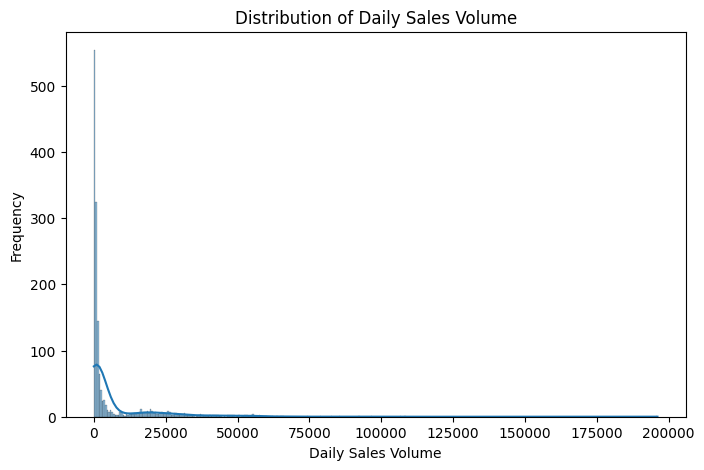

In [9]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_reg_final['daily_sales_volume'],
    kde=True
)

plt.title("Distribution of Daily Sales Volume")
plt.xlabel("Daily Sales Volume")
plt.ylabel("Frequency")

plt.show()

### Distribution of Numerical Features

The distributions of the numerical predictor features are examined to
understand their spread, concentration, and possible skewness before
preprocessing and regression modeling.

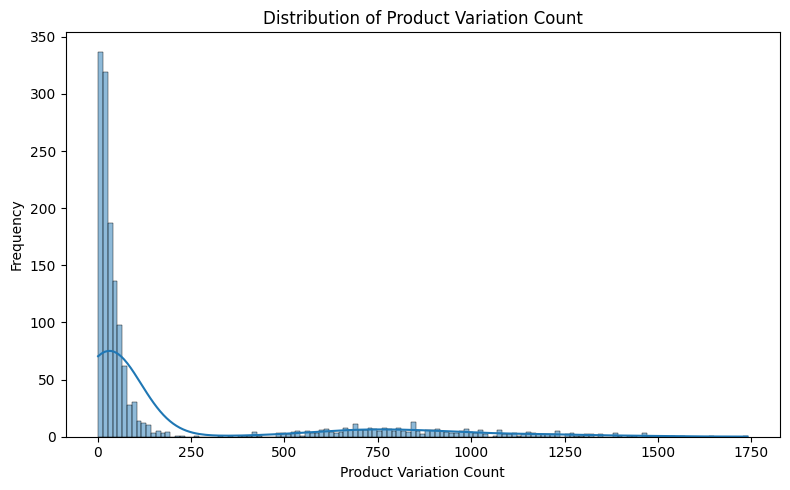

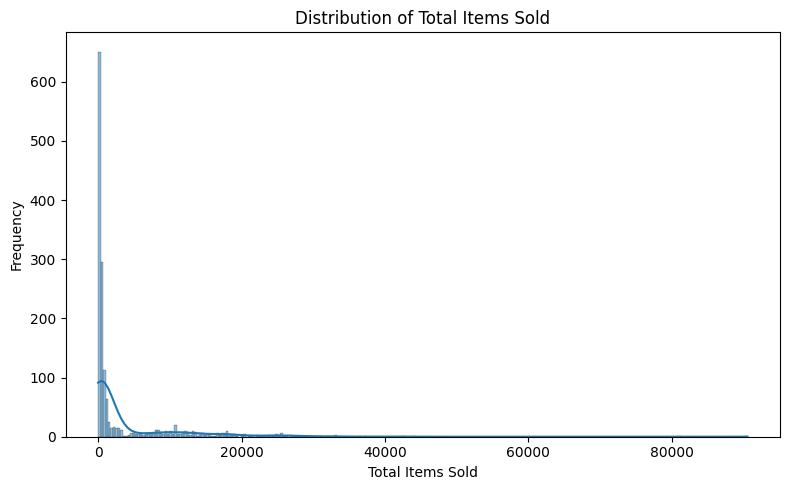

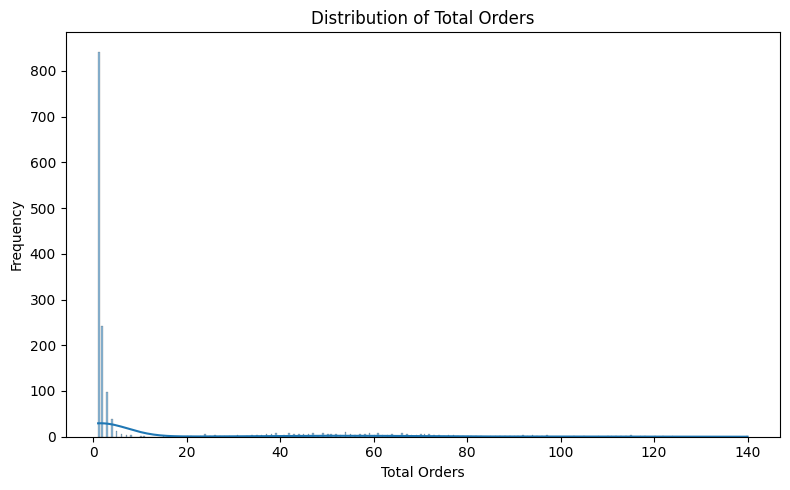

In [10]:
numeric_features = [
    'product_variation_count',
    'total_items_sold',
    'total_orders'
]

for feature in numeric_features:
    plt.figure(figsize=(8, 5))
    
    sns.histplot(
        data=df_reg_final,
        x=feature,
        kde=True
    )
    
    plt.title(f"Distribution of {feature.replace('_', ' ').title()}")
    plt.xlabel(feature.replace('_', ' ').title())
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

### Observation

The graph shows how daily sales values are spread across the dataset. Most values are concentrated in one range, while some days have much higher sales.

## 2. Correlation Heatmap

The correlation heatmap shows how the numerical features are related to each other and to the target variable.

A value close to 1 means a strong positive relationship, while a value close to -1 means a strong negative relationship.

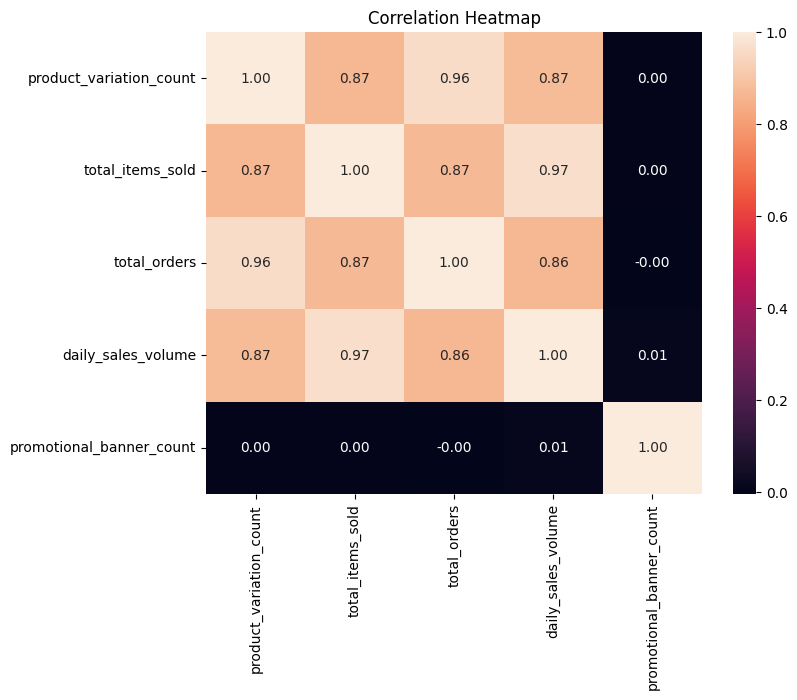

In [11]:
numeric_cols = df_reg_final.select_dtypes(
    include=[np.number]
).columns

plt.figure(figsize=(8, 6))

sns.heatmap(
    df_reg_final[numeric_cols].corr(),
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows the strength of the relationships between the numerical features. The values help us identify which features have a stronger relationship with daily sales volume.

## 3. Product Variation vs Daily Sales

This scatter plot shows the relationship between the number of different products sold and daily sales volume.

It helps us understand whether selling more product varieties is related to higher sales.

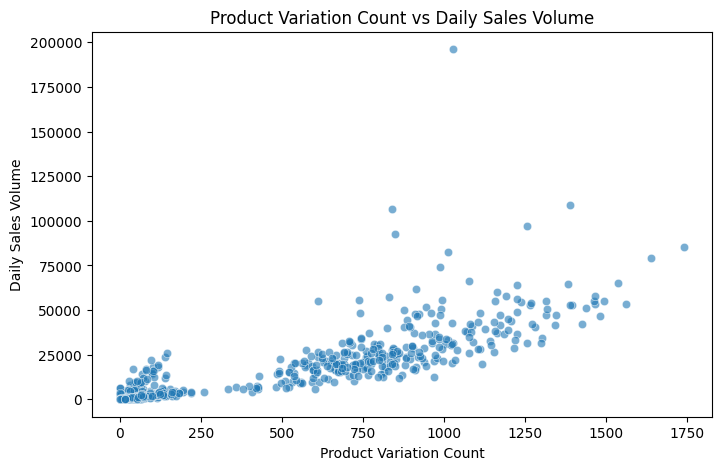

In [12]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_reg_final,
    x='product_variation_count',
    y='daily_sales_volume',
    alpha=0.6
)

plt.title("Product Variation Count vs Daily Sales Volume")
plt.xlabel("Product Variation Count")
plt.ylabel("Daily Sales Volume")

plt.show()

### Observation

The scatter plot shows the relationship between product variety and daily sales volume. The points help us see whether sales generally increase when more product varieties are sold.

## 4. Total Orders vs Daily Sales

This scatter plot shows the relationship between the number of orders and daily sales volume.

It helps us understand whether days with more orders also have higher sales.

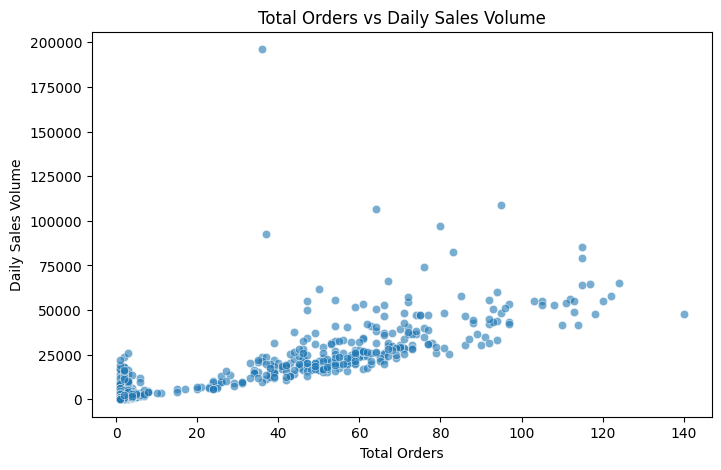

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df_reg_final,
    x='total_orders',
    y='daily_sales_volume',
    alpha=0.6
)

plt.title("Total Orders vs Daily Sales Volume")
plt.xlabel("Total Orders")
plt.ylabel("Daily Sales Volume")

plt.show()

## EDA Observations

- `product_variation_count`, `total_items_sold`, and `total_orders` are
  right-skewed, with most observations having lower values and a few having
  substantially higher values.

- `daily_sales_volume` is also right-skewed, with a small number of
  observations showing very high sales.

- The correlation heatmap shows strong positive relationships between the
  activity-related features and `daily_sales_volume`.

- Both scatter plots show that higher product variation and higher order
  activity are generally associated with higher daily sales.

- The plots indicate some unusually high values, which will be examined as
  potential outliers during preprocessing.

## Section B: Preprocessing and Feature Engineering

In this section, we prepare the dataset for machine learning.

We will:
- Check and handle missing values
- Remove duplicate rows
- Convert the date into useful features
- Create a new feature
- Check and handle outliers
- Separate the features and target
- Split the data into training and testing sets
- Encode categorical features
- Scale numerical features

## Load the Data

First, we load the aggregated dataset that was created during the EDA step.

The target variable is `daily_sales_volume`, which is the value we want to predict.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

SEED = 42
TARGET = 'daily_sales_volume'

df = pd.read_csv(
    r'C:\Users\muthu\OneDrive\Desktop\ML-Capstone-Project\data\raw\data_1.csv',
    encoding='ISO-8859-1'
)

print("Original dataset shape:", df.shape)

Original dataset shape: (1554, 7)


## 1. Check Missing Values

Before cleaning the data, we check if any values are missing.

Missing values can cause problems when training a machine learning model, so they need to be handled properly.

In [15]:
df_reg_clean = df.copy()

print("\nMissing values before treatment:")
print(df_reg_clean.isnull().sum())


Missing values before treatment:
Date                        0
Country                     0
product_variation_count     0
total_items_sold            0
total_orders                0
daily_sales_volume          0
promotional_banner_count    0
dtype: int64


## 2. Handle Missing Values

For numerical columns, missing values are replaced with the median value.

For categorical columns, missing values are replaced with `Unknown`.

This allows us to keep the available data instead of removing rows unnecessarily.

In [16]:
# Numerical columns -> median
numeric_cols = df_reg_clean.select_dtypes(
    include=[np.number]
).columns

for col in numeric_cols:
    if df_reg_clean[col].isnull().sum() > 0:
        df_reg_clean[col] = df_reg_clean[col].fillna(
            df_reg_clean[col].median()
        )

# Categorical columns -> Unknown
categorical_cols = df_reg_clean.select_dtypes(
    include=['object', 'category']
).columns

for col in categorical_cols:
    if df_reg_clean[col].isnull().sum() > 0:
        df_reg_clean[col] = df_reg_clean[col].fillna(
            'Unknown'
        )

print("Missing values after treatment:")
print(df_reg_clean.isnull().sum())

Missing values after treatment:
Date                        0
Country                     0
product_variation_count     0
total_items_sold            0
total_orders                0
daily_sales_volume          0
promotional_banner_count    0
dtype: int64


## 3. Remove Duplicate Rows

Duplicate rows contain the same information more than once.

We remove duplicate rows so that the same observation is not used multiple times.

In [17]:
# Duplicate removal
duplicates_count = df_reg_clean.duplicated().sum()

df_reg_clean = (
    df_reg_clean
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f"\nDuplicate rows removed: {duplicates_count}")
print("Shape after cleaning:", df_reg_clean.shape)


Duplicate rows removed: 0
Shape after cleaning: (1554, 7)


## 4. Create Date Features

The `Date` column contains information about when the sales happened.

Instead of using the complete date directly, we create three simple features:

- `year` — the year of the sale
- `month` — the month of the sale
- `day_of_week` — the day of the week

These features can help the model learn seasonal and weekly patterns.

In [18]:
df_reg_clean['Date'] = pd.to_datetime(
    df_reg_clean['Date'],
    errors='coerce'
)

df_reg_clean['year'] = df_reg_clean['Date'].dt.year
df_reg_clean['month'] = df_reg_clean['Date'].dt.month
df_reg_clean['day_of_week'] = df_reg_clean['Date'].dt.dayofweek

df_reg_clean.drop(
    columns=['Date'],
    inplace=True
)

print("Date features created successfully.")
print(df_reg_clean[['year', 'month', 'day_of_week']].head())

Date features created successfully.
   year  month  day_of_week
0  2010     12            2
1  2010     12            2
2  2010     12            2
3  2010     12            2
4  2010     12            2


## Feature Engineering

Feature engineering means creating a new feature from the existing data.

Here, we create `avg_items_per_order`.

This feature shows the average number of items in each order for a particular country on a particular day.

In [19]:
# Cognitive Friction Index
df_reg_clean['avg_items_per_order'] = (
    df_reg_clean['total_items_sold'] /
    df_reg_clean['total_orders']
)

print("Created feature: avg_items_per_order")

Created feature: avg_items_per_order


## Remove Unnecessary Features

The `promotional_banner_count` feature is removed because it was created using random values and is not part of the original dataset.

The other useful features are kept for the regression models.

In [20]:
columns_to_remove = [
    'promotional_banner_count'
]

df_reg_clean.drop(
    columns=[
        col for col in columns_to_remove
        if col in df_reg_clean.columns
    ],
    inplace=True
)

print("\nRemoved redundant/synthetic features:")
print([
    col for col in columns_to_remove
    if col in df.columns
])


Removed redundant/synthetic features:
['promotional_banner_count']


## Separate Features and Target

The target is the value that we want the model to predict.

Here, the target is `daily_sales_volume`.

All the other columns are used as input features.

In [21]:
X = df_reg_clean.drop(
    columns=[TARGET]
)

# Keep the original target for final evaluation
y_original = df_reg_clean[TARGET].clip(lower=0)

print("Features shape:", X.shape)
print("Target shape:", y_original.shape)

Features shape: (1554, 8)
Target shape: (1554,)


## Transform the Target Variable

Daily sales volume can have some very large values.

We use a log transformation to reduce the effect of these very large values and make the target easier for the models to learn.

In [22]:
y = np.log1p(y_original)

print("Target transformation completed.")

Target transformation completed.


## Train-Test Split

We divide the data into two parts:

- **80% training data** — used to train the models
- **20% testing data** — used to evaluate the models

We use stratification so that the training and testing sets have a similar distribution of the target values.

In [23]:
y_bins = pd.qcut(
    y,
    q=10,
    labels=False,
    duplicates='drop'
)

(
    X_train,
    X_test,
    y_train,
    y_test,
    y_train_original,
    y_test_original
) = train_test_split(
    X,
    y,
    y_original,
    test_size=0.20,
    random_state=SEED,
    stratify=y_bins
)

print("\nTrain/Test split:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


Train/Test split:
X_train: (1243, 8)
X_test : (311, 8)
y_train: (1243,)
y_test : (311,)


## Check and Handle Outliers

An outlier is a value that is much higher or lower than most other values.

We use the IQR method to find unusual values in the continuous feature.

The limits are calculated using only the training data. This prevents information from the test data from affecting the training process.

In [24]:
continuous_features = [
    'product_variation_count',
    'total_items_sold',
    'total_orders',
    'avg_items_per_order'
]

outlier_bounds = {}

print("\nPredictor outlier audit:")

for col in continuous_features:

    if col not in X_train.columns:
        continue

    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outlier_bounds[col] = (lower, upper)

    count = (
        (X_train[col] < lower) |
        (X_train[col] > upper)
    ).sum()

    print(
        f"{col}: {count} outliers "
        f"[{lower:.2f}, {upper:.2f}]"
    )

    # Apply training-derived bounds
    X_train[col] = X_train[col].clip(
        lower,
        upper
    )

    X_test[col] = X_test[col].clip(
        lower,
        upper
    )



Predictor outlier audit:
product_variation_count: 243 outliers [-96.00, 200.00]
total_items_sold: 255 outliers [-2673.00, 4967.00]
total_orders: 247 outliers [-2.00, 6.00]
avg_items_per_order: 127 outliers [-196.00, 724.00]


## Check Target Outliers

We also check for unusual values in the target variable.

The outlier limits are calculated using the training target only.

We then limit the training target values to these limits.

The test target is left unchanged because it should represent the real data used for final evaluation.

In [25]:
# Calculate bounds using training target only
Q1_y = y_train.quantile(0.25)
Q3_y = y_train.quantile(0.75)
IQR_y = Q3_y - Q1_y

lower_y = Q1_y - 1.5 * IQR_y
upper_y = Q3_y + 1.5 * IQR_y

target_outliers = (
    (y_train < lower_y) |
    (y_train > upper_y)
).sum()

print(
    f"\nTarget outliers in training data: "
    f"{target_outliers}"
)

print(
    f"Target IQR bounds: "
    f"[{lower_y:.4f}, {upper_y:.4f}]"
)

# Cap training target only
y_train = y_train.clip(
    lower_y,
    upper_y
)


Target outliers in training data: 6
Target IQR bounds: [2.5977, 11.5446]


## Identify Feature Types

Machine learning models handle numerical and categorical data differently.

We separate the columns into two groups:

- Numerical features
- Categorical features

In [26]:
categorical_cols = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=[np.number]
).columns.tolist()

print("Categorical features:")
print(categorical_cols)

print("\nNumerical features:")
print(numerical_cols)

Categorical features:
['Country']

Numerical features:
['product_variation_count', 'total_items_sold', 'total_orders', 'year', 'month', 'day_of_week', 'avg_items_per_order']


## Handle Rare Countries

Some countries may have very few records.

We group countries that appear fewer than 5 times into `Other`.

The country counts are calculated using the training data only.

In [27]:
if 'Country' in X_train.columns:

    country_counts = X_train['Country'].value_counts()

    rare_countries = country_counts[
        country_counts < 5
    ].index

    X_train['Country'] = X_train['Country'].replace(
        rare_countries,
        'Other'
    )

    X_test['Country'] = X_test['Country'].replace(
        rare_countries,
        'Other'
    )

    print(
        "Rare countries grouped into 'Other':",
        len(rare_countries)
    )

Rare countries grouped into 'Other': 10


## Encoding and Scaling

Machine learning models work better when the input data is prepared properly.

For numerical features, we use `StandardScaler` to put the values on a similar scale.

For categorical features, we use `OneHotEncoder` to convert categories into numerical values.

The encoder and scaler are fitted only on the training data.

In [28]:
# Update feature lists after handling rare countries
categorical_cols = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

numerical_cols = X_train.select_dtypes(
    include=[np.number]
).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numerical_cols
        ),
        (
            'cat',
            OneHotEncoder(
                drop='first',
                handle_unknown='ignore',
                sparse_output=False
            ),
            categorical_cols
        )
    ]
)

## Fit the Preprocessor on Training Data

The scaler and encoder are fitted using only the training data.

The test data is only transformed using the information learned from the training data.

This helps prevent data leakage.

In [29]:
# Fit ONLY on training data
X_train_processed = preprocessor.fit_transform(
    X_train
)

# Transform test using training parameters
X_test_processed = preprocessor.transform(
    X_test
)

c:\Users\muthu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


## Create the Final Processed Data

After encoding and scaling, we convert the results back into DataFrames.

This makes the processed data easier to view and use in the next section.

In [30]:
feature_names = (
    preprocessor.get_feature_names_out()
)

X_train_scaled = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

print("Processed training data:", X_train_scaled.shape)
print("Processed testing data :", X_test_scaled.shape)

Processed training data: (1243, 33)
Processed testing data : (311, 33)


## Final Preprocessing Check

Finally, we check the processed data.

We make sure that:
- The train and test data have the expected sizes.
- There are no missing values.
- The final features are ready for model training.

In [31]:
print("=" * 50)
print("PREPROCESSING COMPLETE")
print("=" * 50)

print("\nFinal shapes:")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)
print("y_train       :", y_train.shape)
print("y_test        :", y_test.shape)

print("\nMissing values:")
print("X_train:", X_train_scaled.isnull().sum().sum())
print("X_test :", X_test_scaled.isnull().sum().sum())
print("y_train:", y_train.isnull().sum())
print("y_test :", y_test.isnull().sum())

print("\nFinal features:")
print(X_train_scaled.columns.tolist())

print("\nPreprocessing completed successfully.")

PREPROCESSING COMPLETE

Final shapes:
X_train_scaled: (1243, 33)
X_test_scaled : (311, 33)
y_train       : (1243,)
y_test        : (311,)

Missing values:
X_train: 0
X_test : 0
y_train: 0
y_test : 0

Final features:
['num__product_variation_count', 'num__total_items_sold', 'num__total_orders', 'num__year', 'num__month', 'num__day_of_week', 'num__avg_items_per_order', 'cat__Country_Austria', 'cat__Country_Belgium', 'cat__Country_Canada', 'cat__Country_Channel Islands', 'cat__Country_Cyprus', 'cat__Country_Denmark', 'cat__Country_EIRE', 'cat__Country_Finland', 'cat__Country_France', 'cat__Country_Germany', 'cat__Country_Hong Kong', 'cat__Country_Iceland', 'cat__Country_Israel', 'cat__Country_Italy', 'cat__Country_Japan', 'cat__Country_Netherlands', 'cat__Country_Norway', 'cat__Country_Other', 'cat__Country_Poland', 'cat__Country_Portugal', 'cat__Country_Singapore', 'cat__Country_Spain', 'cat__Country_Sweden', 'cat__Country_Switzerland', 'cat__Country_United Kingdom', 'cat__Country_Unspec

In [32]:
train_processed = X_train_scaled.copy()
train_processed['target'] = y_train.values

test_processed = X_test_scaled.copy()
test_processed['target'] = y_test.values

train_processed.to_csv(
    r'C:\Users\muthu\OneDrive\Desktop\ML-Capstone-Project\data\processed\train_processed.csv',
    index=False
)

test_processed.to_csv(
    r'C:\Users\muthu\OneDrive\Desktop\ML-Capstone-Project\data\processed\test_processed.csv',
    index=False
)

print("Processed training and testing data saved successfully.")

Processed training and testing data saved successfully.


## Section C. Regression

In this section, we build regression models to predict `daily_sales_volume`.

We first train five regression algorithms:

1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. ElasticNet Regression
5. Polynomial Regression

All models use the same training and testing datasets so that their results can be compared fairly.

## Import Regression Algorithms

The required regression algorithms and evaluation metrics are imported from Scikit-learn.

The models will be trained using the preprocessed training data created in Section B.

In [33]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

## 1. Linear Regression

Linear Regression is used as the baseline model.

It tries to find a linear relationship between the input features and the target variable `daily_sales_volume`.

In [34]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_pred_log = linear_model.predict(X_test_scaled)

linear_pred = np.expm1(linear_pred_log)
linear_pred = np.maximum(linear_pred, 0)

linear_r2 = r2_score(y_test_original, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test_original, linear_pred))
linear_mae = mean_absolute_error(y_test_original, linear_pred)

print("Linear Regression")
print("R2   :", round(linear_r2, 4))
print("RMSE :", round(linear_rmse, 4))
print("MAE  :", round(linear_mae, 4))

Linear Regression
R2   : 0.8427
RMSE : 4758.5432
MAE  : 1993.7796


## 2. Ridge Regression

Ridge Regression is similar to Linear Regression but adds L2 regularisation.

Regularisation helps reduce the effect of very large coefficients and can improve model stability.

In [35]:
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

ridge_pred_log = ridge_model.predict(X_test_scaled)

ridge_pred = np.expm1(ridge_pred_log)
ridge_pred = np.maximum(ridge_pred, 0)

ridge_r2 = r2_score(y_test_original, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test_original, ridge_pred))
ridge_mae = mean_absolute_error(y_test_original, ridge_pred)

print("Ridge Regression")
print("R2   :", round(ridge_r2, 4))
print("RMSE :", round(ridge_rmse, 4))
print("MAE  :", round(ridge_mae, 4))

Ridge Regression
R2   : 0.8427
RMSE : 4759.9168
MAE  : 1992.158


## 3. Lasso Regression

Lasso Regression uses L1 regularisation.

It can reduce some model coefficients towards zero, which can help simplify the model.

In [36]:
lasso_model = Lasso(
    alpha=0.01,
    max_iter=10000
)

lasso_model.fit(X_train_scaled, y_train)

lasso_pred_log = lasso_model.predict(X_test_scaled)

lasso_pred = np.expm1(lasso_pred_log)
lasso_pred = np.maximum(lasso_pred, 0)

lasso_r2 = r2_score(y_test_original, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test_original, lasso_pred))
lasso_mae = mean_absolute_error(y_test_original, lasso_pred)

print("Lasso Regression")
print("R2   :", round(lasso_r2, 4))
print("RMSE :", round(lasso_rmse, 4))
print("MAE  :", round(lasso_mae, 4))

Lasso Regression
R2   : 0.834
RMSE : 4888.6524
MAE  : 1983.814


## 4. ElasticNet Regression

ElasticNet combines L1 and L2 regularisation.

It can provide a balance between the properties of Lasso and Ridge Regression.

In [37]:
elastic_model = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    max_iter=10000
)

elastic_model.fit(X_train_scaled, y_train)

elastic_pred_log = elastic_model.predict(X_test_scaled)

elastic_pred = np.expm1(elastic_pred_log)
elastic_pred = np.maximum(elastic_pred, 0)

elastic_r2 = r2_score(y_test_original, elastic_pred)
elastic_rmse = np.sqrt(mean_squared_error(y_test_original, elastic_pred))
elastic_mae = mean_absolute_error(y_test_original, elastic_pred)

print("ElasticNet Regression")
print("R2   :", round(elastic_r2, 4))
print("RMSE :", round(elastic_rmse, 4))
print("MAE  :", round(elastic_mae, 4))

ElasticNet Regression
R2   : 0.8373
RMSE : 4840.6615
MAE  : 1977.2514


## 5. Polynomial Regression – Initial Approach

Polynomial Regression extends Linear Regression by creating polynomial features.

This allows the model to learn non-linear relationships between the input features and the target.

We start with degree 2 and will compare different polynomial degrees separately.

In [38]:
polynomial_model = Pipeline([
    (
        "polynomial_features",
        PolynomialFeatures(
            degree=2,
            include_bias=False
        )
    ),
    (
        "linear_regression",
        LinearRegression()
    )
])

polynomial_model.fit(X_train_scaled, y_train)

polynomial_pred_log = polynomial_model.predict(X_test_scaled)

polynomial_pred = np.expm1(polynomial_pred_log)
polynomial_pred = np.maximum(polynomial_pred, 0)

polynomial_r2 = r2_score(
    y_test_original,
    polynomial_pred
)

polynomial_rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        polynomial_pred
    )
)

polynomial_mae = mean_absolute_error(
    y_test_original,
    polynomial_pred
)

print("Polynomial Regression (Initial Approach) - Degree 2")
print("R2   :", round(polynomial_r2, 4))
print("RMSE :", round(polynomial_rmse, 4))
print("MAE  :", round(polynomial_mae, 4))

Polynomial Regression (Initial Approach) - Degree 2
R2   : -3712565661.6071
RMSE : 731160223.7949
MAE  : 41462325.8989


Polynomial Features(degree=2), applied to all 32 preprocessed columns, which means the model created polynomial combinations between:

- numerical features
- year/month/day
- every country dummy variable
- interactions between country variables
- squared country variables

This created a very large and unstable set of features.

In [39]:
from sklearn.compose import ColumnTransformer

# Select all numerical columns
poly_numeric_features = [
    'num__product_variation_count',
    'num__total_items_sold',
    'num__total_orders',
    'num__year',
    'num__month',
    'num__day_of_week',
    'num__avg_items_per_order'
]

# Select categorical columns
categorical_features = [
    col for col in X_train_scaled.columns
    if col.startswith('cat__')
]

# Create polynomial features only for numerical variables
poly_transformer = ColumnTransformer(
    transformers=[
        (
            'polynomial',
            PolynomialFeatures(
                degree=2,
                include_bias=False
            ),
            poly_numeric_features
        )
    ],
    remainder='passthrough'
)

# Polynomial Regression model
polynomial_model = Pipeline([
    ('polynomial_features', poly_transformer),
    ('linear_regression', LinearRegression())
])

# Train
polynomial_model.fit(X_train_scaled, y_train)

# Predict
polynomial_pred_log = polynomial_model.predict(X_test_scaled)

# Convert predictions back from log scale
polynomial_pred = np.expm1(polynomial_pred_log)
polynomial_pred = np.maximum(polynomial_pred, 0)

# Evaluate
polynomial_r2 = r2_score(
    y_test_original,
    polynomial_pred
)

polynomial_rmse = np.sqrt(
    mean_squared_error(
        y_test_original,
        polynomial_pred
    )
)

polynomial_mae = mean_absolute_error(
    y_test_original,
    polynomial_pred
)

print("Polynomial Regression (Corrected) - Degree 2")
print("R2   :", round(polynomial_r2, 4))
print("RMSE :", round(polynomial_rmse, 4))
print("MAE  :", round(polynomial_mae, 4))

Polynomial Regression (Corrected) - Degree 2
R2   : 0.8658
RMSE : 4395.7077
MAE  : 1748.6771


We changed it so polynomial features are created only for the numerical features:

- product_variation_count
- total_items_sold
- total_orders
- year
- month
- day_of_week
- avg_items_per_order

we corrected the feature expansion approach.

## Regression Model Comparison

The five regression models are compared using three evaluation metrics:

- **R²**: Measures how well the model explains the variation in the target.
- **RMSE**: Measures the average prediction error, with larger errors receiving more weight.
- **MAE**: Measures the average absolute prediction error.

The models are ranked based on R², with the highest R² ranked first.

In [40]:
results = [
    {
        "Model": "Linear Regression",
        "R2": linear_r2,
        "RMSE": linear_rmse,
        "MAE": linear_mae
    },
    {
        "Model": "Ridge Regression",
        "R2": ridge_r2,
        "RMSE": ridge_rmse,
        "MAE": ridge_mae
    },
    {
        "Model": "Lasso Regression",
        "R2": lasso_r2,
        "RMSE": lasso_rmse,
        "MAE": lasso_mae
    },
    {
        "Model": "ElasticNet Regression",
        "R2": elastic_r2,
        "RMSE": elastic_rmse,
        "MAE": elastic_mae
    },
    {
        "Model": "Polynomial Regression",
        "R2": polynomial_r2,
        "RMSE": polynomial_rmse,
        "MAE": polynomial_mae
    }
]

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

comparison_df.insert(
    0,
    "Rank",
    range(1, len(comparison_df) + 1)
)

display(
    comparison_df.style.format({
        "R2": "{:.4f}",
        "RMSE": "{:.2f}",
        "MAE": "{:.2f}"
    })
)

,Rank,Model,R2,RMSE,MAE
0,1,Polynomial Regression,0.8658,4395.71,1748.68
1,2,Linear Regression,0.8427,4758.54,1993.78
2,3,Ridge Regression,0.8427,4759.92,1992.16
3,4,ElasticNet Regression,0.8373,4840.66,1977.25
4,5,Lasso Regression,0.8340,4888.65,1983.81


### Best Performing Model

The model with the highest R² score is considered the best-performing model among these five algorithms.

The final model selection will be made after all required regression algorithms are evaluated and compared.

In [41]:
best_model_name = comparison_df.iloc[0]["Model"]

print("Best model among the first five:", best_model_name)
print("R2 score:", round(comparison_df.iloc[0]["R2"], 4))

Best model among the first five: Polynomial Regression
R2 score: 0.8658


## R² Comparison of the First Five Models

The R² scores of the five regression models are visualised below.

A higher R² value indicates better performance.

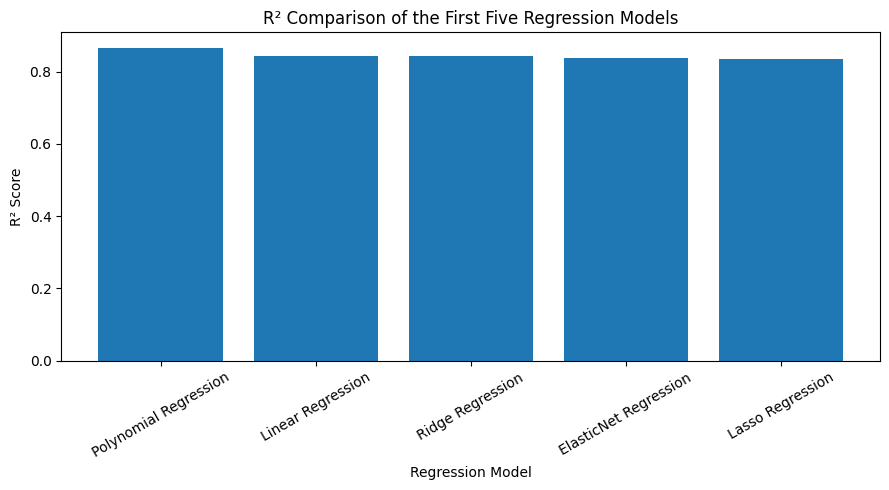

In [42]:
plt.figure(figsize=(9, 5))

plt.bar(comparison_df["Model"], comparison_df["R2"])

plt.title("R² Comparison of the First Five Regression Models")
plt.xlabel("Regression Model")
plt.ylabel("R² Score")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Observation

The bar chart compares the R² scores of the five regression models.

The model with the highest R² performs best among these five models.

## Polynomial Regression Degree Comparison

Polynomial Regression can use different polynomial degrees.

Here, Degree 2 and Degree 3 are compared using polynomial features for the numerical variables only. The categorical country features are kept unchanged.

This comparison helps determine whether increasing the polynomial degree improves model performance.

In [43]:
polynomial_results = []

for degree in [2, 3]:

    # Apply polynomial transformation only to numerical features
    poly_transformer = ColumnTransformer(
        transformers=[
            (
                'polynomial',
                PolynomialFeatures(
                    degree=degree,
                    include_bias=False
                ),
                poly_numeric_features
            )
        ],
        remainder='passthrough'
    )

    # Create polynomial regression pipeline
    model = Pipeline([
        (
            'polynomial_features',
            poly_transformer
        ),
        (
            'linear_regression',
            LinearRegression()
        )
    ])

    # Train the model
    model.fit(
        X_train_scaled,
        y_train
    )

    # Predict
    pred_log = model.predict(
        X_test_scaled
    )

    # Convert predictions back to original scale
    pred = np.expm1(pred_log)
    pred = np.maximum(pred, 0)

    # Calculate metrics
    r2 = r2_score(
        y_test_original,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_original,
            pred
        )
    )

    mae = mean_absolute_error(
        y_test_original,
        pred
    )

    polynomial_results.append({
        'Degree': degree,
        'R2': r2,
        'RMSE': rmse,
        'MAE': mae
    })


degree_comparison_df = pd.DataFrame(
    polynomial_results
)

display(
    degree_comparison_df.style.format({
        'R2': '{:.4f}',
        'RMSE': '{:.2f}',
        'MAE': '{:.2f}'
    })
)

,Degree,R2,RMSE,MAE
0,2,0.8658,4395.71,1748.68
1,3,0.8214,5071.13,1872.75


## Polynomial Degree Comparison Graph

The R² scores for the different polynomial degrees are shown below.

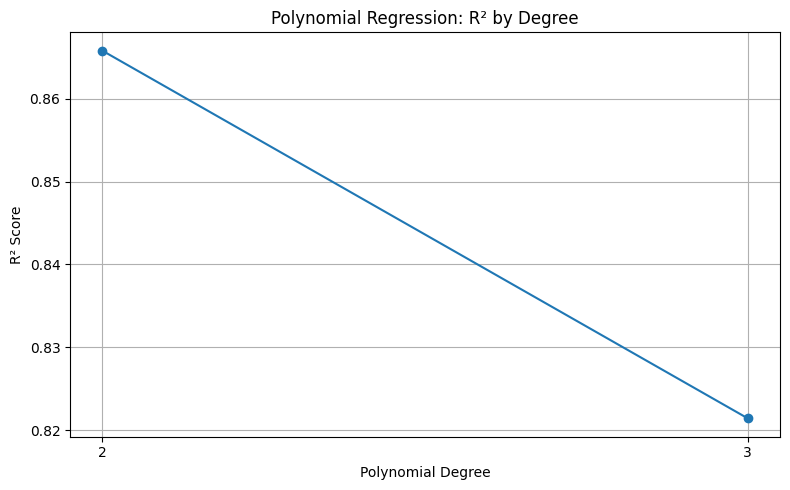

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(
    degree_comparison_df['Degree'],
    degree_comparison_df['R2'],
    marker='o'
)

plt.xlabel('Polynomial Degree')
plt.ylabel('R² Score')
plt.title('Polynomial Regression: R² by Degree')

plt.xticks([2, 3])
plt.grid(True)

plt.tight_layout()
plt.show()

In [45]:
print(X_train_scaled.columns.tolist())

['num__product_variation_count', 'num__total_items_sold', 'num__total_orders', 'num__year', 'num__month', 'num__day_of_week', 'num__avg_items_per_order', 'cat__Country_Austria', 'cat__Country_Belgium', 'cat__Country_Canada', 'cat__Country_Channel Islands', 'cat__Country_Cyprus', 'cat__Country_Denmark', 'cat__Country_EIRE', 'cat__Country_Finland', 'cat__Country_France', 'cat__Country_Germany', 'cat__Country_Hong Kong', 'cat__Country_Iceland', 'cat__Country_Israel', 'cat__Country_Italy', 'cat__Country_Japan', 'cat__Country_Netherlands', 'cat__Country_Norway', 'cat__Country_Other', 'cat__Country_Poland', 'cat__Country_Portugal', 'cat__Country_Singapore', 'cat__Country_Spain', 'cat__Country_Sweden', 'cat__Country_Switzerland', 'cat__Country_United Kingdom', 'cat__Country_Unspecified']
